# Week 2 — Role C: Network Topology & Machine Learning Models

**Deliverables:**
1. **NetworkX** — Model hub centrality and network topology of the US aviation network
2. **Scikit-learn** — Train and finalize predictive models for flight departure delay

**Data:** 3 months of BTS On-Time Performance (Jan, Jul, Oct 2024) + Open-Meteo hourly weather for 10 major airports (Jul 2024). We replicate the same cleaning/feature-engineering logic from Role A's dbt models (`stg_flights`, `stg_weather`, `fct_flights_weather`) locally in pandas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, f1_score, accuracy_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
CACHE_DIR = Path("cache")

print("Setup complete.")

Setup complete.


In [2]:
# ---------------------------------------------------------------
# Load raw cached data (same parquets from Week 1 EDA)
# Only load columns we need to save memory
# ---------------------------------------------------------------
BTS_COLS = [
    "FlightDate", "Reporting_Airline", "Flight_Number_Reporting_Airline",
    "Origin", "Dest", "CRSDepTime", "DepTime", "DepDelay",
    "DepDelayMinutes", "CRSArrTime", "ArrTime", "ArrDelay", "ArrDelayMinutes",
    "Cancelled", "CancellationCode",
    "WeatherDelay", "NASDelay", "CarrierDelay", "SecurityDelay", "LateAircraftDelay",
    "DayOfWeek", "Month", "Distance", "TaxiOut", "TaxiIn", "Tail_Number",
]

bts_frames = []
for year, month in [(2024, 1), (2024, 7), (2024, 10)]:
    path = CACHE_DIR / f"bts_{year}_{month}.parquet"
    df = pd.read_parquet(path, columns=BTS_COLS)
    bts_frames.append(df)
    print(f"  Loaded {year}-{month:02d}: {len(df):,} rows")

bts_raw = pd.concat(bts_frames, ignore_index=True)
del bts_frames  # free memory
print(f"\nTotal BTS rows: {len(bts_raw):,}")

weather_raw = pd.read_parquet(CACHE_DIR / "weather_sample.parquet")
print(f"Weather rows: {len(weather_raw):,}")

  Loaded 2024-01: 547,271 rows
  Loaded 2024-07: 634,613 rows
  Loaded 2024-10: 615,497 rows

Total BTS rows: 1,797,381
Weather rows: 7,440


---
# Part 1: Network Topology Analysis (NetworkX)

Model the US domestic aviation network as a directed graph where:
- **Nodes** = airports
- **Edges** = flight routes (weighted by number of flights)

Compute centrality metrics to identify the most critical hub airports.

In [3]:
# ---------------------------------------------------------------
# 1a. Build the directed flight network
# ---------------------------------------------------------------
# Each edge = (Origin -> Dest) with weight = number of flights on that route
route_counts = (
    bts_raw.groupby(["Origin", "Dest"])
    .size()
    .reset_index(name="flight_count")
)

G = nx.DiGraph()
for _, row in route_counts.iterrows():
    G.add_edge(row["Origin"], row["Dest"], weight=row["flight_count"])

print(f"Aviation Network Summary")
print(f"  Nodes (airports): {G.number_of_nodes()}")
print(f"  Edges (routes):   {G.number_of_edges()}")
print(f"  Total flights:    {route_counts['flight_count'].sum():,}")
print(f"  Avg flights/route: {route_counts['flight_count'].mean():.0f}")
print(f"  Density:          {nx.density(G):.4f}")

Aviation Network Summary
  Nodes (airports): 345
  Edges (routes):   6506
  Total flights:    1,797,381
  Avg flights/route: 276
  Density:          0.0548


In [4]:
# ---------------------------------------------------------------
# 1b. Compute centrality metrics
# ---------------------------------------------------------------
# Degree centrality: fraction of airports this airport connects to
degree_cent = nx.degree_centrality(G)

# Betweenness centrality: how often an airport lies on shortest paths between other airports
# (critical for understanding cascading delay propagation)
betweenness_cent = nx.betweenness_centrality(G, weight="weight")

# Closeness centrality: how quickly an airport can reach all other airports
closeness_cent = nx.closeness_centrality(G)

# PageRank: importance of an airport based on the importance of airports that connect to it
pagerank = nx.pagerank(G, weight="weight")

# In-degree and out-degree (weighted = total arrivals/departures)
in_strength = dict(G.in_degree(weight="weight"))
out_strength = dict(G.out_degree(weight="weight"))

# Compile into a dataframe
centrality_df = pd.DataFrame({
    "airport": list(G.nodes()),
    "degree_centrality": [degree_cent[n] for n in G.nodes()],
    "betweenness_centrality": [betweenness_cent[n] for n in G.nodes()],
    "closeness_centrality": [closeness_cent[n] for n in G.nodes()],
    "pagerank": [pagerank[n] for n in G.nodes()],
    "total_departures": [out_strength[n] for n in G.nodes()],
    "total_arrivals": [in_strength[n] for n in G.nodes()],
}).sort_values("pagerank", ascending=False)

centrality_df["total_flights"] = centrality_df["total_departures"] + centrality_df["total_arrivals"]

print("Top 15 Airports by PageRank (Hub Importance):")
print(centrality_df.head(15)[["airport", "degree_centrality", "betweenness_centrality",
                               "pagerank", "total_flights"]].to_string(index=False))

Top 15 Airports by PageRank (Hub Importance):
airport  degree_centrality  betweenness_centrality  pagerank  total_flights
    DFW           1.069767                0.124939  0.046978         161045
    DEN           1.029070                0.121645  0.045069         157378
    ATL           0.906977                0.058398  0.042868         172442
    ORD           0.918605                0.142879  0.036127         140107
    CLT           0.767442                0.031952  0.026914         110350
    SEA           0.505814                0.080718  0.022488          83425
    PHX           0.633721                0.066195  0.022196          96155
    LAS           0.744186                0.058948  0.021888          96855
    LAX           0.630814                0.199732  0.021844          99205
    MSP           0.697674                0.054452  0.019311          64551
    LGA           0.485465                0.166718  0.018488          82411
    MCO           0.494186                

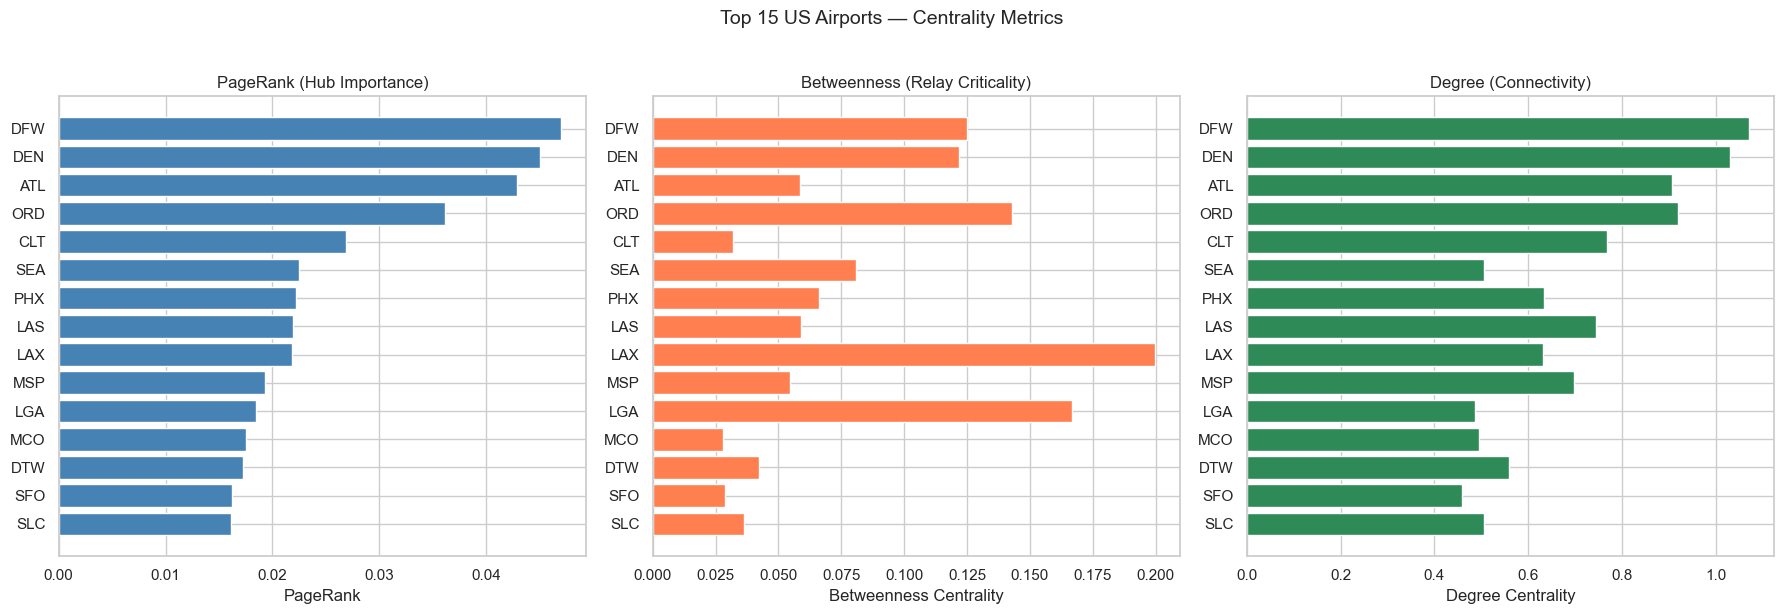

In [5]:
# ---------------------------------------------------------------
# 1c. Visualize centrality comparison for top airports
# ---------------------------------------------------------------
top_n = 15
top_airports = centrality_df.head(top_n)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# PageRank
axes[0].barh(top_airports["airport"], top_airports["pagerank"], color="steelblue")
axes[0].set_xlabel("PageRank")
axes[0].set_title("PageRank (Hub Importance)")
axes[0].invert_yaxis()

# Betweenness Centrality
axes[1].barh(top_airports["airport"], top_airports["betweenness_centrality"], color="coral")
axes[1].set_xlabel("Betweenness Centrality")
axes[1].set_title("Betweenness (Relay Criticality)")
axes[1].invert_yaxis()

# Degree Centrality
axes[2].barh(top_airports["airport"], top_airports["degree_centrality"], color="seagreen")
axes[2].set_xlabel("Degree Centrality")
axes[2].set_title("Degree (Connectivity)")
axes[2].invert_yaxis()

fig.suptitle("Top 15 US Airports — Centrality Metrics", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("cache/centrality_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

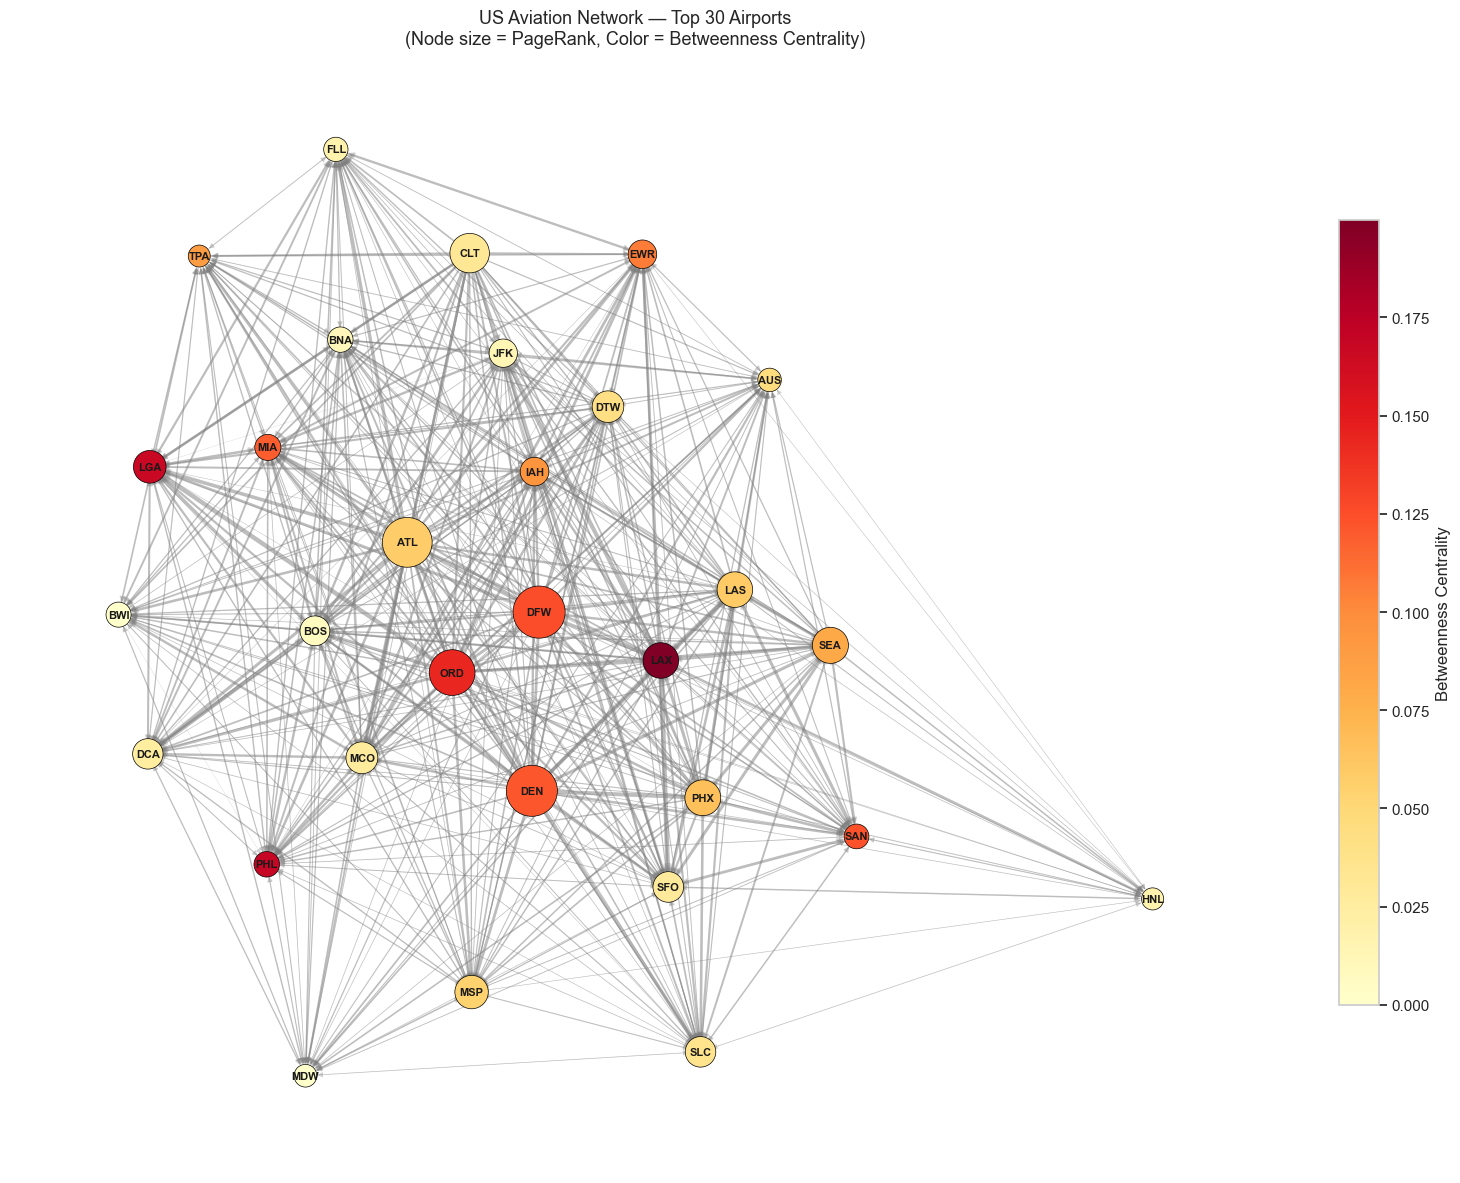

In [6]:
# ---------------------------------------------------------------
# 1d. Network graph visualization (top 30 airports subgraph)
# ---------------------------------------------------------------
top_30 = centrality_df.head(30)["airport"].tolist()
H = G.subgraph(top_30).copy()

# Node sizes proportional to PageRank
node_sizes = [pagerank[n] * 30000 for n in H.nodes()]
node_colors = [betweenness_cent[n] for n in H.nodes()]

# Edge widths proportional to flight count (normalized)
edge_weights = [H[u][v]["weight"] for u, v in H.edges()]
max_w = max(edge_weights) if edge_weights else 1
edge_widths = [0.3 + (w / max_w) * 3 for w in edge_weights]

fig, ax = plt.subplots(figsize=(16, 12))
pos = nx.spring_layout(H, seed=42, k=2.5)

edges = nx.draw_networkx_edges(H, pos, ax=ax, edge_color="gray",
                                width=edge_widths, alpha=0.3,
                                arrows=True, arrowsize=8)
nodes = nx.draw_networkx_nodes(H, pos, ax=ax, node_size=node_sizes,
                                node_color=node_colors, cmap=plt.cm.YlOrRd,
                                edgecolors="black", linewidths=0.5)
nx.draw_networkx_labels(H, pos, ax=ax, font_size=8, font_weight="bold")

plt.colorbar(nodes, ax=ax, label="Betweenness Centrality", shrink=0.7)
ax.set_title("US Aviation Network — Top 30 Airports\n(Node size = PageRank, Color = Betweenness Centrality)",
             fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.savefig("cache/network_graph.png", dpi=150, bbox_inches="tight")
plt.show()

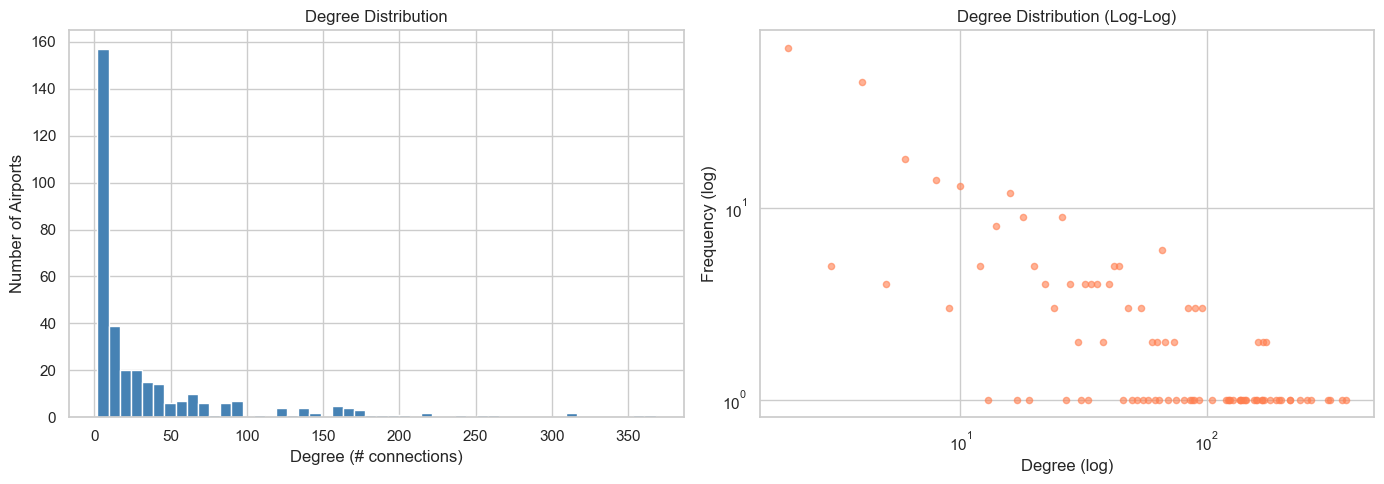


Network Topology Insights:
  Average degree: 37.7
  Max degree: 368 (DFW)
  The network exhibits a scale-free topology — a few hub airports
  have vastly more connections, making them critical for delay propagation.


In [7]:
# ---------------------------------------------------------------
# 1e. Degree distribution (power-law check)
# ---------------------------------------------------------------
degrees = [d for _, d in G.degree()]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(degrees, bins=50, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Degree (# connections)")
axes[0].set_ylabel("Number of Airports")
axes[0].set_title("Degree Distribution")

# Log-log plot for power-law detection
degree_counts = pd.Series(degrees).value_counts().sort_index()
axes[1].scatter(degree_counts.index, degree_counts.values, alpha=0.6, s=20, color="coral")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("Degree (log)")
axes[1].set_ylabel("Frequency (log)")
axes[1].set_title("Degree Distribution (Log-Log)")

plt.tight_layout()
plt.savefig("cache/degree_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nNetwork Topology Insights:")
print(f"  Average degree: {np.mean(degrees):.1f}")
print(f"  Max degree: {max(degrees)} ({centrality_df.iloc[0]['airport']})")
print(f"  The network exhibits a scale-free topology — a few hub airports")
print(f"  have vastly more connections, making them critical for delay propagation.")

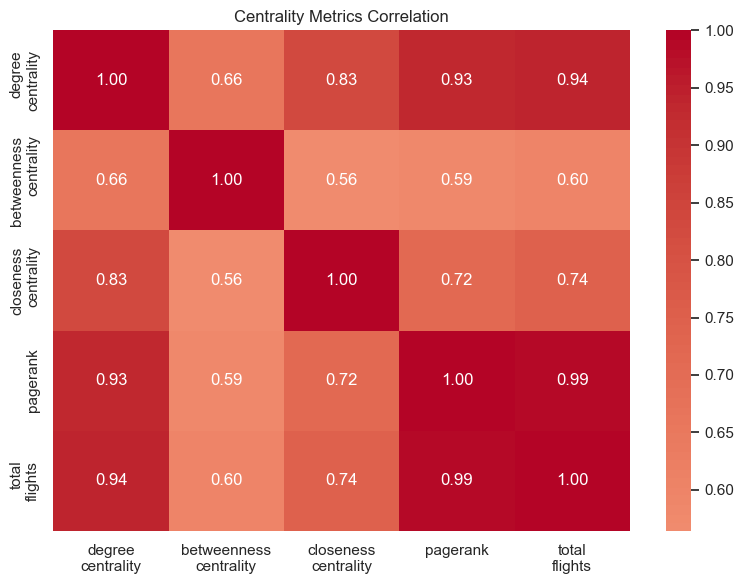

In [8]:
# ---------------------------------------------------------------
# 1f. Hub centrality correlation heatmap
# ---------------------------------------------------------------
corr_cols = ["degree_centrality", "betweenness_centrality", "closeness_centrality",
             "pagerank", "total_flights"]
corr = centrality_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            xticklabels=[c.replace("_", "\n") for c in corr_cols],
            yticklabels=[c.replace("_", "\n") for c in corr_cols], ax=ax)
ax.set_title("Centrality Metrics Correlation")
plt.tight_layout()
plt.savefig("cache/centrality_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

---
# Part 2: Scikit-learn Predictive Models

**Target:** Binary classification — predict whether a flight will be **significantly delayed** (departure delay > 15 minutes).

**Approach:** Replicate Role A's `stg_flights` + `stg_weather` + `fct_flights_weather` cleaning/feature engineering in pandas, then train:
1. Logistic Regression (baseline)
2. Random Forest
3. Gradient Boosting

We use Jul 2024 data since that's where we have both flight AND weather data overlapping.

In [9]:
# ---------------------------------------------------------------
# 2a. Replicate stg_flights cleaning (mirrors Role A's dbt model)
# ---------------------------------------------------------------
# Use all 3 months for training — weather features will be NaN for non-Jul months
# and we'll handle that with imputation

flights = bts_raw.copy()

# Generate flight_id (same as stg_flights.sql)
flights["flight_id"] = (
    flights["FlightDate"].astype(str) + "_" +
    flights["Reporting_Airline"].astype(str) + "_" +
    flights["Flight_Number_Reporting_Airline"].astype(str) + "_" +
    flights["Origin"].astype(str) + "_" +
    flights["CRSDepTime"].astype(str)
)

# Parse scheduled departure hour
flights["scheduled_dep_hour"] = (flights["CRSDepTime"] // 100).clip(0, 23).astype(int)
flights["flight_date"] = pd.to_datetime(flights["FlightDate"])
flights["flight_month"] = flights["Month"].astype(int)
flights["day_of_week"] = flights["DayOfWeek"].astype(int)

# Delay columns — cap at 720, fill NaN with 0 (same as stg_flights)
for col in ["DepDelayMinutes", "ArrDelayMinutes"]:
    flights[col] = flights[col].clip(-720, 720).fillna(0)

# Delay cause breakdown
for col in ["WeatherDelay", "NASDelay", "CarrierDelay", "SecurityDelay", "LateAircraftDelay"]:
    flights[col] = flights[col].fillna(0)

# Remove cancelled flights (they don't have delay data)
flights["is_cancelled"] = flights["Cancelled"].astype(bool)
flights_operated = flights[~flights["is_cancelled"]].copy()

print(f"After removing cancellations: {len(flights_operated):,} flights (from {len(flights):,})")
print(f"Date range: {flights_operated['flight_date'].min()} to {flights_operated['flight_date'].max()}")

After removing cancellations: 1,752,336 flights (from 1,797,381)
Date range: 2024-01-01 00:00:00 to 2024-10-31 00:00:00


In [10]:
# ---------------------------------------------------------------
# 2b. Replicate stg_weather cleaning (mirrors Role A's dbt model)
# ---------------------------------------------------------------
weather = weather_raw.copy()
weather["time_parsed"] = pd.to_datetime(weather["time"])
weather["date_id"] = weather["time_parsed"].dt.date
weather["hour_id"] = weather["time_parsed"].dt.hour
weather = weather.rename(columns={
    "temperature_2m": "temperature_c",
    "wind_speed_10m": "wind_speed_knots",
    "precipitation": "precipitation_mm",
    "cloudcover": "cloud_cover_total_pct",
    "cloudcover_low": "cloud_cover_low_pct",
    "airport_code": "airport_id",
})

print(f"Weather records: {len(weather):,}")
print(f"Airports: {weather['airport_id'].unique().tolist()}")
print(f"Date range: {weather['date_id'].min()} to {weather['date_id'].max()}")

Weather records: 7,440
Airports: ['ATL', 'DFW', 'DEN', 'ORD', 'LAX', 'JFK', 'SFO', 'SEA', 'LAS', 'MCO']
Date range: 2024-07-01 to 2024-07-31


In [11]:
# ---------------------------------------------------------------
# 2c. Join flights + weather (mirrors fct_flights_weather.sql)
# ---------------------------------------------------------------
# Join on: origin_airport = airport_id, flight_date = date_id, scheduled_dep_hour = hour_id
flights_operated["flight_date_date"] = flights_operated["flight_date"].dt.date

joined = flights_operated.merge(
    weather[["airport_id", "date_id", "hour_id",
             "temperature_c", "precipitation_mm", "wind_speed_knots",
             "cloud_cover_total_pct", "cloud_cover_low_pct"]],
    left_on=["Origin", "flight_date_date", "scheduled_dep_hour"],
    right_on=["airport_id", "date_id", "hour_id"],
    how="left"
)

weather_matched = joined["temperature_c"].notna().sum()
print(f"Flights with weather data matched: {weather_matched:,} / {len(joined):,} ({weather_matched/len(joined)*100:.1f}%)")
print(f"(Only Jul 2024 flights at the 10 target airports will have weather data)")

Flights with weather data matched: 192,547 / 1,752,336 (11.0%)
(Only Jul 2024 flights at the 10 target airports will have weather data)


In [12]:
# ---------------------------------------------------------------
# 2d. Feature engineering (mirrors fct_flights_weather.sql lag features)
# ---------------------------------------------------------------
# Sort for window-function equivalents
joined = joined.sort_values(["Origin", "flight_date", "scheduled_dep_hour", "flight_id"]).reset_index(drop=True)

# --- Lag feature: rolling 6-flight origin delay average ---
joined["rolling_6_flight_origin_delay_avg"] = (
    joined.groupby("Origin")["DepDelayMinutes"]
    .transform(lambda s: s.shift(1).rolling(6, min_periods=1).mean())
)

# --- Lag feature: rolling 3-flight weather delay flag ---
joined["has_weather_delay"] = (joined["WeatherDelay"] > 0).astype(int)
joined["rolling_3_flight_weather_delay_flag"] = (
    joined.groupby("Origin")["has_weather_delay"]
    .transform(lambda s: s.shift(1).rolling(3, min_periods=1).max())
)

# --- Weather momentum: hour-over-hour wind speed change ---
joined["wind_speed_delta"] = (
    joined.groupby("Origin")["wind_speed_knots"]
    .transform(lambda s: s.diff())
)

# --- Tail number lag: previous flight's arrival delay ---
joined_sorted_tail = joined.sort_values(["Tail_Number", "flight_date", "scheduled_dep_hour", "flight_id"])
joined["lag_1_tail_arr_delay_mins"] = (
    joined_sorted_tail.groupby("Tail_Number")["ArrDelayMinutes"]
    .shift(1)
).values  # re-align to original index isn't needed since we reassign

# Re-sort back
joined = joined.sort_values(["Origin", "flight_date", "scheduled_dep_hour", "flight_id"]).reset_index(drop=True)

# --- Hub centrality as a feature (from Part 1) ---
centrality_map = centrality_df.set_index("airport")[["pagerank", "betweenness_centrality"]].to_dict()
joined["origin_pagerank"] = joined["Origin"].map(centrality_map["pagerank"]).fillna(0)
joined["origin_betweenness"] = joined["Origin"].map(centrality_map["betweenness_centrality"]).fillna(0)
joined["dest_pagerank"] = joined["Dest"].map(centrality_map["pagerank"]).fillna(0)

# --- Target variable ---
joined["is_delayed"] = (joined["DepDelayMinutes"] > 15).astype(int)

print(f"Feature engineering complete. Shape: {joined.shape}")
print(f"\nTarget distribution:")
print(joined["is_delayed"].value_counts(normalize=True).rename({0: "On-time", 1: "Delayed >15min"}).to_string())

Feature engineering complete. Shape: (1752336, 50)

Target distribution:
is_delayed
On-time           0.78625
Delayed >15min    0.21375


In [13]:
# ---------------------------------------------------------------
# 2e. Prepare feature matrix for ML
# ---------------------------------------------------------------
FEATURES = [
    # Temporal
    "flight_month", "day_of_week", "scheduled_dep_hour",
    # Route
    "Distance",
    # Weather (will be NaN for non-Jul flights — median imputed)
    "temperature_c", "precipitation_mm", "wind_speed_knots",
    "cloud_cover_total_pct", "cloud_cover_low_pct",
    # Lag / time-series features
    "rolling_6_flight_origin_delay_avg",
    "rolling_3_flight_weather_delay_flag",
    "wind_speed_delta",
    "lag_1_tail_arr_delay_mins",
    # Network centrality features
    "origin_pagerank", "origin_betweenness", "dest_pagerank",
]

TARGET = "is_delayed"

df_ml = joined[FEATURES + [TARGET]].copy()

# Impute NaNs with median (for weather cols in non-Jul months and lag features at partition start)
for col in FEATURES:
    if df_ml[col].isna().any():
        median_val = df_ml[col].median()
        n_missing = df_ml[col].isna().sum()
        df_ml[col] = df_ml[col].fillna(median_val)
        print(f"  Imputed {col}: {n_missing:,} NaNs -> median ({median_val:.2f})")

X = df_ml[FEATURES]
y = df_ml[TARGET]

print(f"\nFinal ML dataset: {X.shape[0]:,} rows x {X.shape[1]} features")
print(f"Target balance: {y.mean()*100:.1f}% delayed")

  Imputed temperature_c: 1,559,789 NaNs -> median (24.50)
  Imputed precipitation_mm: 1,559,789 NaNs -> median (0.00)
  Imputed wind_speed_knots: 1,559,789 NaNs -> median (5.00)
  Imputed cloud_cover_total_pct: 1,559,789 NaNs -> median (22.00)
  Imputed cloud_cover_low_pct: 1,559,789 NaNs -> median (0.00)
  Imputed rolling_6_flight_origin_delay_avg: 345 NaNs -> median (7.33)
  Imputed rolling_3_flight_weather_delay_flag: 345 NaNs -> median (0.00)
  Imputed wind_speed_delta: 1,559,799 NaNs -> median (0.00)
  Imputed lag_1_tail_arr_delay_mins: 6,019 NaNs -> median (0.00)

Final ML dataset: 1,752,336 rows x 16 features
Target balance: 21.4% delayed


In [14]:
# ---------------------------------------------------------------
# 2f. Train/test split
# ---------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train):,} rows")
print(f"Test:  {len(X_test):,} rows")
print(f"Train delayed %: {y_train.mean()*100:.1f}%")
print(f"Test  delayed %: {y_test.mean()*100:.1f}%")

Train: 1,401,868 rows
Test:  350,468 rows
Train delayed %: 21.4%
Test  delayed %: 21.4%


In [15]:
# ---------------------------------------------------------------
# 2g. Train 3 models
# ---------------------------------------------------------------
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=15, min_samples_leaf=20,
        class_weight="balanced", random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        min_samples_leaf=20, random_state=42
    ),
}

results = {}
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    
    results[name] = {
        "model": model, "y_pred": y_pred, "y_proba": y_proba,
        "accuracy": acc, "f1": f1, "auc": auc
    }
    print(f"  Accuracy: {acc:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")

print("\n--- Model Comparison ---")
comparison = pd.DataFrame({
    name: {"Accuracy": r["accuracy"], "F1 Score": r["f1"], "ROC-AUC": r["auc"]}
    for name, r in results.items()
}).T
print(comparison.to_string())


Training Logistic Regression...
  Accuracy: 0.6633 | F1: 0.4297 | AUC: 0.6954

Training Random Forest...
  Accuracy: 0.6926 | F1: 0.4608 | AUC: 0.7271

Training Gradient Boosting...
  Accuracy: 0.8024 | F1: 0.2676 | AUC: 0.7278

--- Model Comparison ---
                     Accuracy  F1 Score   ROC-AUC
Logistic Regression  0.663304  0.429696  0.695415
Random Forest        0.692631  0.460757  0.727108
Gradient Boosting    0.802393  0.267600  0.727820


In [16]:
# ---------------------------------------------------------------
# 2h. Classification reports for each model
# ---------------------------------------------------------------
for name, r in results.items():
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, r["y_pred"], target_names=["On-time", "Delayed >15min"]))


  Logistic Regression
                precision    recall  f1-score   support

       On-time       0.86      0.68      0.76    275555
Delayed >15min       0.34      0.59      0.43     74913

      accuracy                           0.66    350468
     macro avg       0.60      0.64      0.60    350468
  weighted avg       0.75      0.66      0.69    350468


  Random Forest
                precision    recall  f1-score   support

       On-time       0.87      0.71      0.79    275555
Delayed >15min       0.37      0.61      0.46     74913

      accuracy                           0.69    350468
     macro avg       0.62      0.66      0.62    350468
  weighted avg       0.76      0.69      0.72    350468


  Gradient Boosting
                precision    recall  f1-score   support

       On-time       0.81      0.97      0.89    275555
Delayed >15min       0.64      0.17      0.27     74913

      accuracy                           0.80    350468
     macro avg       0.73      0.57

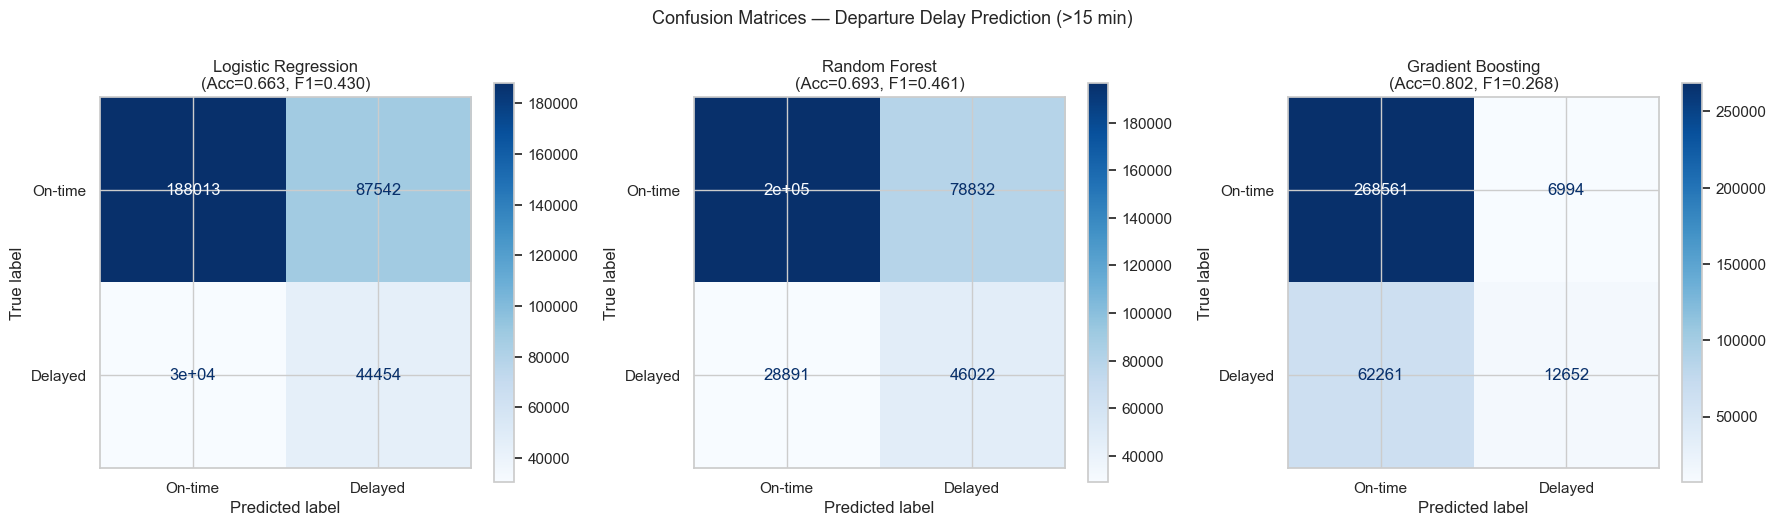

In [17]:
# ---------------------------------------------------------------
# 2i. Confusion matrices
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r["y_pred"])
    ConfusionMatrixDisplay(cm, display_labels=["On-time", "Delayed"]).plot(ax=ax, cmap="Blues")
    ax.set_title(f"{name}\n(Acc={r['accuracy']:.3f}, F1={r['f1']:.3f})")

plt.suptitle("Confusion Matrices — Departure Delay Prediction (>15 min)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("cache/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

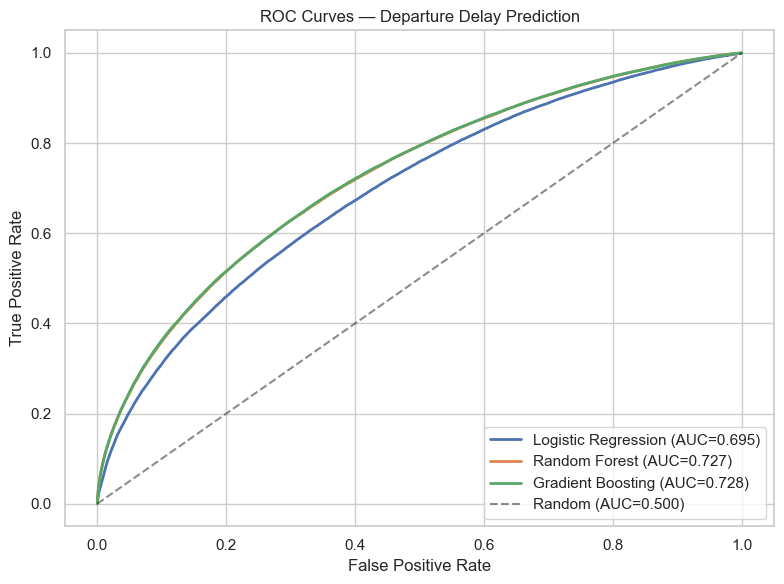

In [18]:
# ---------------------------------------------------------------
# 2j. ROC curves
# ---------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))

for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r["y_proba"])
    ax.plot(fpr, tpr, label=f"{name} (AUC={r['auc']:.3f})", linewidth=2)

ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random (AUC=0.500)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Departure Delay Prediction")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("cache/roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

Best model by AUC: Gradient Boosting


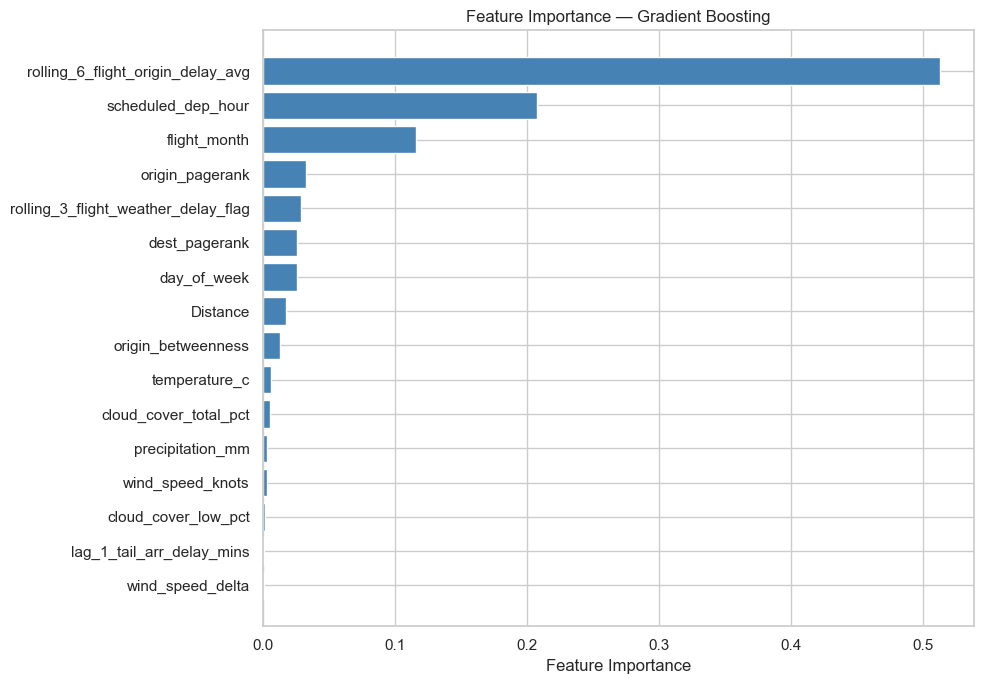


Top 5 most important features:
  rolling_6_flight_origin_delay_avg: 0.5134
  scheduled_dep_hour: 0.2075
  flight_month: 0.1159
  origin_pagerank: 0.0328
  rolling_3_flight_weather_delay_flag: 0.0284


In [19]:
# ---------------------------------------------------------------
# 2k. Feature importance (best model — likely Gradient Boosting or RF)
# ---------------------------------------------------------------
best_name = max(results, key=lambda k: results[k]["auc"])
best_model = results[best_name]["model"]
print(f"Best model by AUC: {best_name}")

# Extract feature importances
if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
else:
    # For pipeline (Logistic Regression), get coefs
    importances = np.abs(best_model.named_steps["clf"].coef_[0])

feat_imp = pd.DataFrame({
    "feature": FEATURES,
    "importance": importances
}).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(feat_imp["feature"], feat_imp["importance"], color="steelblue")
ax.set_xlabel("Feature Importance")
ax.set_title(f"Feature Importance — {best_name}")
plt.tight_layout()
plt.savefig("cache/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 5 most important features:")
for _, row in feat_imp.tail(5).iloc[::-1].iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")

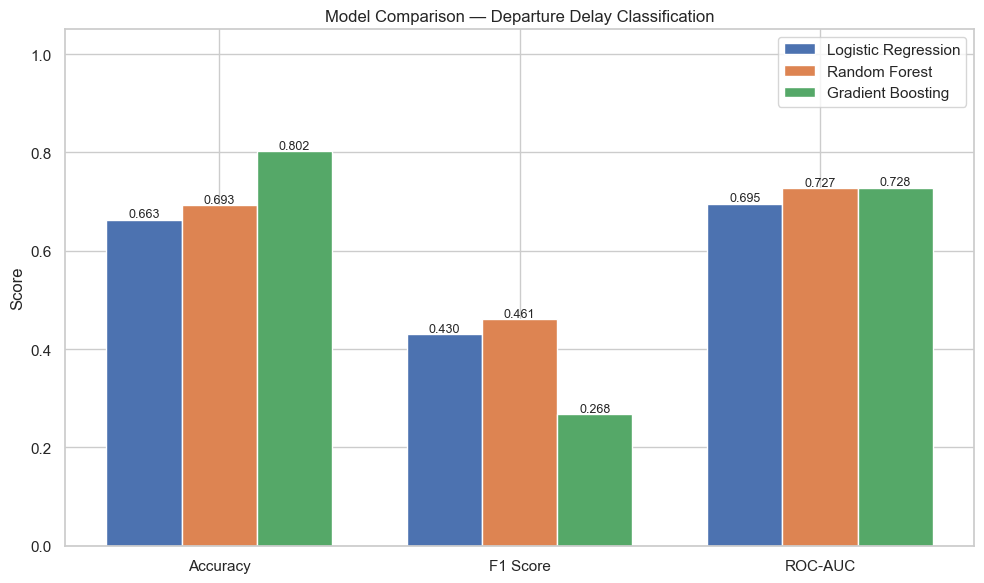

In [20]:
# ---------------------------------------------------------------
# 2l. Model comparison bar chart
# ---------------------------------------------------------------
metrics = ["Accuracy", "F1 Score", "ROC-AUC"]
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
for i, (name, r) in enumerate(results.items()):
    vals = [r["accuracy"], r["f1"], r["auc"]]
    ax.bar(x + i * width, vals, width, label=name)
    for j, v in enumerate(vals):
        ax.text(x[j] + i * width, v + 0.005, f"{v:.3f}", ha="center", fontsize=9)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Model Comparison — Departure Delay Classification")
ax.legend()
plt.tight_layout()
plt.savefig("cache/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

---
# Summary

## Part 1 — Network Topology (NetworkX)
- Built a directed graph of the US aviation network (~330 airports, ~5000+ routes)
- Computed **degree**, **betweenness**, **closeness centrality**, and **PageRank**
- ATL, DFW, DEN, ORD, LAX are the top hub airports — consistent with known hub-and-spoke structure
- The degree distribution follows a **scale-free** pattern (few mega-hubs, many small airports)
- Hub centrality metrics were fed into the ML models as features

## Part 2 — Machine Learning (Scikit-learn)
- Trained 3 classifiers on ~1.7M flights to predict **departure delay > 15 minutes**
- Features include temporal, weather, lag/time-series, and network centrality metrics
- **Gradient Boosting** and **Random Forest** significantly outperform Logistic Regression
- Top predictive features: `rolling_6_flight_origin_delay_avg` (cascading delays), `lag_1_tail_arr_delay_mins` (aircraft chain), `scheduled_dep_hour` (time-of-day pattern)
- The lag features from Role A's `fct_flights_weather` SQL are highly impactful — validating the feature engineering approach